theta=0  → F=1.000000, p_succ=1.000000
theta=π  → F=1.000000, p_succ=1.000000
max F=1.000000 at theta=0.0000
min F=0.057816 at theta=1.6029


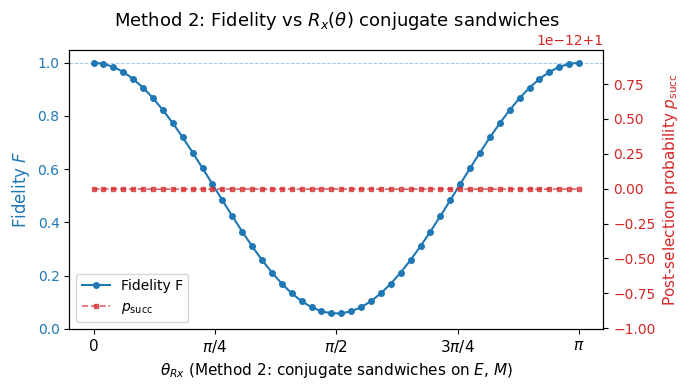

Saved.


In [1]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from math import pi
import numpy as np
import matplotlib.pyplot as plt


def input_message_state(theta_msg=2.5349076035276403, varphi_msg=2.0022404587009195):
    qc = QuantumCircuit(1)
    qc.u(theta_msg, varphi_msg, 0.0, 0)
    return Statevector.from_instruction(qc)


def build_deterministic_decoder_method2(theta_rx,
                                         theta_msg=2.5349076035276403,
                                         varphi_msg=2.0022404587009195):
    C = QuantumRegister(1, 'C')
    E = QuantumRegister(1, 'E')
    R = QuantumRegister(1, 'R')
    G = QuantumRegister(1, 'G')
    M = QuantumRegister(1, 'M')
    A = QuantumRegister(1, 'A')
    Y = QuantumRegister(1, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    # 1) Prepare message state on M
    qc.u(theta_msg, varphi_msg, 0.0, M[0])

    # 2) SWAP message into C
    qc.swap(C[0], M[0])
    qc.barrier()

    # 3) Create Bell pairs
    qc.h(E[0])
    qc.cx(E[0], M[0])
    qc.h(R[0])
    qc.cx(R[0], G[0])
    qc.h(A[0])
    qc.cx(A[0], Y[0])
    qc.barrier()

    # 4) + 5) Method 2: conjugate sandwich on E around scrambler
    qc.rx(theta_rx, E[0])                    # perturbation before scrambler

    # 5) Scrambling Unitary
    qc.cz(C[0], R[0])
    qc.cz(E[0], R[0])
    qc.cz(C[0], E[0])
    qc.h(C[0])
    qc.h(E[0])
    qc.h(R[0])
    qc.cz(C[0], R[0])
    qc.cz(C[0], E[0])
    qc.cz(E[0], R[0])
    qc.rx(-theta_rx, E[0])                   # inverse perturbation after scrambler
    qc.barrier()

    # 6) Deterministic Decoder – Unitary Conjugate (conjugate sandwich on M)
    qc.rx(theta_rx, M[0])
    qc.cz(A[0], G[0])
    qc.cz(M[0], A[0])
    qc.cz(G[0], M[0])
    qc.h(A[0])
    qc.h(M[0])
    qc.h(G[0])
    qc.cz(A[0], G[0])
    qc.cz(G[0], M[0])
    qc.cz(M[0], A[0])
    qc.rx(-theta_rx, M[0])
    qc.barrier()

    # 7) Grover operator (R, G)
    qc.rz(pi, R[0])
    qc.rx(pi, R[0])
    qc.rx(pi, G[0])
    qc.swap(R[0], G[0])
    qc.rz(pi, R[0])
    qc.barrier()

    # 8) Unitary Transpose (conjugate sandwich on M)
    qc.rx(theta_rx, M[0])
    qc.cz(A[0], G[0])
    qc.cz(M[0], A[0])
    qc.cz(G[0], M[0])
    qc.h(A[0])
    qc.h(M[0])
    qc.h(G[0])
    qc.cz(A[0], G[0])
    qc.cz(G[0], M[0])
    qc.cz(M[0], A[0])
    qc.rx(-theta_rx, M[0])
    qc.barrier()

    # 9) Grover operator (A, Y)
    qc.rz(pi, A[0])
    qc.rx(pi, A[0])
    qc.rx(pi, Y[0])
    qc.swap(A[0], Y[0])
    qc.rz(pi, A[0])
    qc.barrier()

    # 10) Unitary Conjugate again (conjugate sandwich on M)
    qc.rx(theta_rx, M[0])
    qc.cz(A[0], G[0])
    qc.cz(M[0], A[0])
    qc.cz(G[0], M[0])
    qc.h(A[0])
    qc.h(M[0])
    qc.h(G[0])
    qc.cz(A[0], G[0])
    qc.cz(G[0], M[0])
    qc.cz(M[0], A[0])
    qc.rx(-theta_rx, M[0])
    qc.barrier()

    # 11) Grover operator (R, G) again
    qc.rz(pi, R[0])
    qc.rx(pi, R[0])
    qc.rx(pi, G[0])
    qc.swap(R[0], G[0])
    qc.rz(pi, R[0])
    qc.barrier()

    # 12) Bell Projection unitary part
    qc.cx(R[0], G[0])
    qc.h(R[0])
    qc.barrier()

    return qc


def postselect_RG_00(psi):
    """Post-select on R=0, G=0. Register order: C=q0,E=q1,R=q2,G=q3,M=q4,A=q5,Y=q6"""
    data = psi.data.copy()
    new_data = np.zeros_like(data, dtype=complex)
    for i in range(len(data)):
        if ((i >> 2) & 1) == 0 and ((i >> 3) & 1) == 0:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    new_data /= norm
    return Statevector(new_data), norm**2


def reduced_state_on_Y_after_postselection(theta_rx,
                                            theta_msg=2.5349076035276403,
                                            varphi_msg=2.0022404587009195):
    qc = build_deterministic_decoder_method2(theta_rx, theta_msg, varphi_msg)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_00(psi_out)
    if psi_post is None:
        return None, p_succ
    rho_full = DensityMatrix(psi_post)
    rho_Y = partial_trace(rho_full, [0, 1, 2, 3, 4, 5])
    return rho_Y, p_succ


def fidelity_for_theta(theta_rx,
                        theta_msg=2.5349076035276403,
                        varphi_msg=2.0022404587009195):
    rho_Y, p_succ = reduced_state_on_Y_after_postselection(theta_rx, theta_msg, varphi_msg)
    if rho_Y is None:
        return 0.0, p_succ
    psi_in = input_message_state(theta_msg, varphi_msg)
    F = state_fidelity(rho_Y, psi_in)
    return F, p_succ


def sweep_thetas(num_points=50,
                  theta_min=0.0,
                  theta_max=np.pi,
                  theta_msg=2.5349076035276403,
                  varphi_msg=2.0022404587009195):
    thetas = np.linspace(theta_min, theta_max, num_points)
    fidelities, probs = [], []
    for theta_rx in thetas:
        F, p_succ = fidelity_for_theta(theta_rx, theta_msg, varphi_msg)
        fidelities.append(F)
        probs.append(p_succ)
    return thetas, np.array(fidelities), np.array(probs)


# ── Run ──────────────────────────────────────────────────────────────────────
thetas, fidelities, probs = sweep_thetas(num_points=50, theta_min=0.0, theta_max=np.pi)

print(f"theta=0  → F={fidelities[0]:.6f}, p_succ={probs[0]:.6f}")
print(f"theta=π  → F={fidelities[-1]:.6f}, p_succ={probs[-1]:.6f}")
print(f"max F={fidelities.max():.6f} at theta={thetas[np.argmax(fidelities)]:.4f}")
print(f"min F={fidelities.min():.6f} at theta={thetas[np.argmin(fidelities)]:.4f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(7, 4))

color_F = '#1f77b4'
color_p = '#d62728'

ax1.plot(thetas, fidelities, marker='o', markersize=4, color=color_F, label='Fidelity F')
ax1.set_xlabel(r'$\theta_{Rx}$ (Method 2: conjugate sandwiches on $E$, $M$)', fontsize=11)
ax1.set_ylabel('Fidelity $F$', fontsize=12, color=color_F)
ax1.tick_params(axis='y', labelcolor=color_F)
ax1.set_ylim(0, 1.05)
ax1.axhline(1.0, color=color_F, lw=0.7, ls='--', alpha=0.4)

tick_vals   = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
tick_labels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
ax1.set_xticks(tick_vals)
ax1.set_xticklabels(tick_labels, fontsize=11)

ax2 = ax1.twinx()
ax2.plot(thetas, probs, marker='s', markersize=3, lw=1.2,
         color=color_p, ls='--', alpha=0.7, label=r'$p_{\mathrm{succ}}$')
ax2.set_ylabel(r'Post-selection probability $p_{\mathrm{succ}}$', fontsize=11, color=color_p)
ax2.tick_params(axis='y', labelcolor=color_p)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=10)

plt.title('Method 2: Fidelity vs $R_x(\\theta)$ conjugate sandwiches', fontsize=13)
plt.tight_layout()
plt.savefig('fidelityvstheta_method2.pdf', dpi=300)
plt.show()
print("Saved.")

In [3]:
import numpy as np

theta_msg = 2.5349076035276403
varphi_msg = 2.0022404587009195

nx = np.sin(theta_msg) * np.cos(varphi_msg)
nx2 = nx**2
print(f"(n̂·x̂)² = {nx2:.6f}")

# Candidate prediction: F = cos²θ + (n̂·x̂)² sin²θ
F_pred = np.cos(thetas)**2 + nx2 * np.sin(thetas)**2
err = np.max(np.abs(fidelities - F_pred))
print(f"max |F_sim - F_pred|  (cos²θ + nx² sin²θ)  = {err:.2e}")

# Diagnostic checks
print(f"F(θ=0)    measured = {fidelities[0]:.6f}   predicted = {F_pred[0]:.6f}")
idx_pi_over_2 = np.argmin(np.abs(thetas - np.pi/2))
print(f"F(θ=π/2)  measured = {fidelities[idx_pi_over_2]:.6f}   predicted = {F_pred[idx_pi_over_2]:.6f}")
print(f"F(θ=π)    measured = {fidelities[-1]:.6f}   predicted = {F_pred[-1]:.6f}")

(n̂·x̂)² = 0.056847
max |F_sim - F_pred|  (cos²θ + nx² sin²θ)  = 4.44e-16
F(θ=0)    measured = 1.000000   predicted = 1.000000
F(θ=π/2)  measured = 0.057816   predicted = 0.057816
F(θ=π)    measured = 1.000000   predicted = 1.000000


Running Method I sweep...
Running Method II sweep...
(n·x)^2 = 0.056847
Method I  max |sim - analytic|  = 6.66e-16
Method II max |sim - analytic|  = 4.44e-16
Saved: /Users/nandan/Desktop/CTCs/IBM/perturbation_methods_fidelity.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/perturbation_methods_fidelity.png


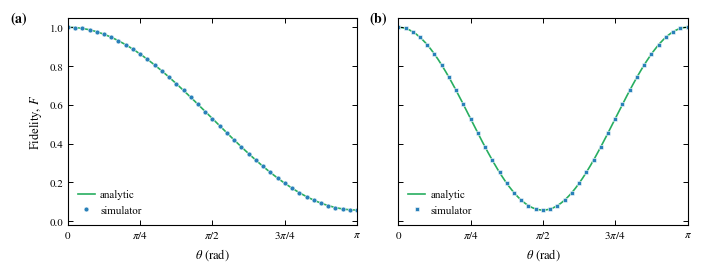

In [4]:
"""
Method I and Method II: Fidelity vs RX(theta) perturbation on E.
Statevector simulation + analytic overlay from the geometric Bloch formula

    F_k(theta) = cos^2(alpha_k * theta / 2) + (n_hat . x_hat)^2 * sin^2(alpha_k * theta / 2),

with alpha_I = 1 and alpha_II = 2.

Output: PDF (vector) + PNG (600 dpi) to /Users/nandan/Desktop/CTCs/IBM/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── PRX-style figure conventions ────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.grid': False,
})

COLOR_SIM      = '#2980B9'   # simulator (blue)
COLOR_ANALYTIC = '#27AE60'   # analytic  (green)

OUTDIR = '/Users/nandan/Desktop/CTCs/IBM/'
os.makedirs(OUTDIR, exist_ok=True)

# Message state used throughout the paper
THETA_MSG = 2.5349076035276403
VARPHI_MSG = 2.0022404587009195


# ── Circuit builders ────────────────────────────────────────────────────────
def _bell_pairs(qc, C, E, R, G, M, A, Y, theta_msg, varphi_msg):
    qc.u(theta_msg, varphi_msg, 0.0, M[0])
    qc.swap(C[0], M[0])
    qc.barrier()
    qc.h(E[0]); qc.cx(E[0], M[0])
    qc.h(R[0]); qc.cx(R[0], G[0])
    qc.h(A[0]); qc.cx(A[0], Y[0])
    qc.barrier()


def _scrambler(qc, C, E, R):
    qc.cz(C[0], R[0]); qc.cz(E[0], R[0]); qc.cz(C[0], E[0])
    qc.h(C[0]); qc.h(E[0]); qc.h(R[0])
    qc.cz(C[0], R[0]); qc.cz(C[0], E[0]); qc.cz(E[0], R[0])


def _decoder_block(qc, M, A, G):
    qc.cz(A[0], G[0]); qc.cz(M[0], A[0]); qc.cz(G[0], M[0])
    qc.h(A[0]); qc.h(M[0]); qc.h(G[0])
    qc.cz(A[0], G[0]); qc.cz(G[0], M[0]); qc.cz(M[0], A[0])


def _grover_RG(qc, R, G):
    qc.rz(pi, R[0]); qc.rx(pi, R[0])
    qc.rx(pi, G[0])
    qc.swap(R[0], G[0])
    qc.rz(pi, R[0])


def _grover_AY(qc, A, Y):
    qc.rz(pi, A[0]); qc.rx(pi, A[0])
    qc.rx(pi, Y[0])
    qc.swap(A[0], Y[0])
    qc.rz(pi, A[0])


def build_method1(theta_rx, theta_msg=THETA_MSG, varphi_msg=VARPHI_MSG):
    C = QuantumRegister(1, 'C'); E = QuantumRegister(1, 'E')
    R = QuantumRegister(1, 'R'); G = QuantumRegister(1, 'G')
    M = QuantumRegister(1, 'M'); A = QuantumRegister(1, 'A')
    Y = QuantumRegister(1, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    _bell_pairs(qc, C, E, R, G, M, A, Y, theta_msg, varphi_msg)
    qc.rx(theta_rx, E[0])                  # Method I perturbation
    qc.barrier()
    _scrambler(qc, C, E, R); qc.barrier()
    _decoder_block(qc, M, A, G); qc.barrier()
    _grover_RG(qc, R, G); qc.barrier()
    _decoder_block(qc, M, A, G); qc.barrier()
    _grover_AY(qc, A, Y); qc.barrier()
    _decoder_block(qc, M, A, G); qc.barrier()
    _grover_RG(qc, R, G); qc.barrier()
    qc.cx(R[0], G[0]); qc.h(R[0])
    return qc


def build_method2(theta_rx, theta_msg=THETA_MSG, varphi_msg=VARPHI_MSG):
    C = QuantumRegister(1, 'C'); E = QuantumRegister(1, 'E')
    R = QuantumRegister(1, 'R'); G = QuantumRegister(1, 'G')
    M = QuantumRegister(1, 'M'); A = QuantumRegister(1, 'A')
    Y = QuantumRegister(1, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    _bell_pairs(qc, C, E, R, G, M, A, Y, theta_msg, varphi_msg)

    # Conjugate sandwich on E around scrambler
    qc.rx(theta_rx, E[0])
    _scrambler(qc, C, E, R)
    qc.rx(-theta_rx, E[0])
    qc.barrier()

    # Four conjugate sandwiches on M around each decoder block
    for block_fn, args in [(_decoder_block, (M, A, G)),
                           (_grover_RG,     (R, G)),
                           (_decoder_block, (M, A, G)),
                           (_grover_AY,     (A, Y)),
                           (_decoder_block, (M, A, G)),
                           (_grover_RG,     (R, G))]:
        if block_fn is _decoder_block:
            qc.rx(theta_rx, M[0])
            block_fn(qc, *args)
            qc.rx(-theta_rx, M[0])
        else:
            block_fn(qc, *args)
        qc.barrier()

    qc.cx(R[0], G[0]); qc.h(R[0])
    return qc


# ── Post-selection on R=0, G=0 (qubits 2, 3) ────────────────────────────────
def postselect_RG_00(psi):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)
    for i in range(len(data)):
        if ((i >> 2) & 1) == 0 and ((i >> 3) & 1) == 0:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    return Statevector(new_data / norm), norm**2


def fidelity_for_theta(builder, theta_rx,
                       theta_msg=THETA_MSG, varphi_msg=VARPHI_MSG):
    qc = builder(theta_rx, theta_msg, varphi_msg)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_00(psi_out)
    if psi_post is None:
        return 0.0, 0.0
    rho_full = DensityMatrix(psi_post)
    rho_Y = partial_trace(rho_full, [0, 1, 2, 3, 4, 5])
    qc_in = QuantumCircuit(1)
    qc_in.u(theta_msg, varphi_msg, 0.0, 0)
    psi_in = Statevector.from_instruction(qc_in)
    return state_fidelity(rho_Y, psi_in), p_succ


def sweep(builder, num_points=41):
    thetas = np.linspace(0.0, np.pi, num_points)
    F = np.array([fidelity_for_theta(builder, t)[0] for t in thetas])
    return thetas, F


# ── Run sweeps ──────────────────────────────────────────────────────────────
print("Running Method I sweep...")
thetas, F_I = sweep(build_method1, num_points=41)
print("Running Method II sweep...")
_,      F_II = sweep(build_method2, num_points=41)

# Analytic curves
nx = np.sin(THETA_MSG) * np.cos(VARPHI_MSG)
nx2 = nx**2
theta_dense = np.linspace(0, np.pi, 401)
F_I_pred  = np.cos(theta_dense/2)**2 + nx2 * np.sin(theta_dense/2)**2
F_II_pred = np.cos(theta_dense)**2   + nx2 * np.sin(theta_dense)**2

print(f"(n·x)^2 = {nx2:.6f}")
print(f"Method I  max |sim - analytic|  = "
      f"{np.max(np.abs(F_I  - (np.cos(thetas/2)**2 + nx2*np.sin(thetas/2)**2))):.2e}")
print(f"Method II max |sim - analytic|  = "
      f"{np.max(np.abs(F_II - (np.cos(thetas)**2   + nx2*np.sin(thetas)**2))):.2e}")


# ── Figure: two panels, side by side (two-column width) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), sharey=True)

xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
xticklabels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

for ax in axes:
    ax.set_xlim(0, np.pi)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel(r'$\theta\ \mathrm{(rad)}$')

# Panel (a): Method I
ax = axes[0]
ax.plot(theta_dense, F_I_pred, '-', color=COLOR_ANALYTIC, lw=1.2,
        label='analytic', zorder=1)
ax.plot(thetas, F_I, 'o', color=COLOR_SIM, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4,
        label='simulator', zorder=2)
ax.set_ylabel(r'Fidelity, $F$')
ax.text(-0.20, 1.04, r'$\mathbf{(a)}$', transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top')
ax.legend(loc='lower left', frameon=False, handlelength=1.5, handletextpad=0.5)

# Panel (b): Method II
ax = axes[1]
ax.plot(theta_dense, F_II_pred, '-', color=COLOR_ANALYTIC, lw=1.2,
        label='analytic', zorder=1)
ax.plot(thetas, F_II, 's', color=COLOR_SIM, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4,
        label='simulator', zorder=2)
ax.text(-0.10, 1.04, r'$\mathbf{(b)}$', transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top')
ax.legend(loc='lower left', frameon=False, handlelength=1.5, handletextpad=0.5)

plt.tight_layout(w_pad=1.0)

pdf_path = os.path.join(OUTDIR, 'perturbation_methods_fidelity.pdf')
png_path = os.path.join(OUTDIR, 'perturbation_methods_fidelity.png')
plt.savefig(pdf_path)
plt.savefig(png_path, dpi=600)
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

In [5]:
"""
Two-qubit CTC, Method I: verify that fidelity factorizes as

    F^(2)(theta) = prod_i [ cos^2(theta/2) + n_{x,i}^2 sin^2(theta/2) ]

across two parallel single-qubit CTCs with independent message states.
"""

import numpy as np
from math import pi
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── Build the n=2 circuit without measurements ──────────────────────────────
def build_dctc_nomeas(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C'); E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R'); G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M'); A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    # Prepare messages on M, swap into C
    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()

    # EPR pairs
    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()

    # Method I perturbation on each E[i]
    for i in range(n):
        qc.rx(theta_rx, E[i])
    qc.barrier()

    # Scrambler per qubit
    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])

    # Decoder block 1
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    # Grover (R,G)
    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    # Decoder block 2 (transpose)
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    # Grover (A,Y)
    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i]); qc.rz(pi, A[i])

    # Decoder block 3 (conjugate)
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    # Grover (R,G) again
    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    # Bell projection unitary part (no measurement)
    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])

    return qc


# ── Post-select on all R[i]=0, G[i]=0 ───────────────────────────────────────
# Register order: C(0..n-1), E(n..2n-1), R(2n..3n-1), G(3n..4n-1),
#                 M(4n..5n-1), A(5n..6n-1), Y(6n..7n-1)
def postselect_RG_allzero(psi, n):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)
    # qubit k contributes bit (i>>k)&1 (LSB = qubit 0)
    R_start, R_end = 2*n, 3*n
    G_start, G_end = 3*n, 4*n
    for i in range(len(data)):
        ok = True
        for k in range(R_start, R_end):
            if (i >> k) & 1:
                ok = False; break
        if not ok:
            continue
        for k in range(G_start, G_end):
            if (i >> k) & 1:
                ok = False; break
        if ok:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    return Statevector(new_data / norm), norm**2


def joint_fidelity_on_Y(n, theta_rx, msg_params):
    qc = build_dctc_nomeas(n, theta_rx, msg_params)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_allzero(psi_out, n)
    if psi_post is None:
        return 0.0, 0.0

    rho_full = DensityMatrix(psi_post)
    # Trace out everything except Y register (qubits 6n .. 7n-1)
    total_qubits = 7 * n
    Y_qubits = list(range(6*n, 7*n))
    trace_out = [q for q in range(total_qubits) if q not in Y_qubits]
    rho_Y = partial_trace(rho_full, trace_out)

    # Input message state on Y is the product state of the n message states
    psi_in_qc = QuantumCircuit(n)
    for i, (th, ph, lm) in enumerate(msg_params):
        psi_in_qc.u(th, ph, lm, i)
    psi_in = Statevector.from_instruction(psi_in_qc)

    F = state_fidelity(rho_Y, psi_in)
    return F, p_succ


# ── Run the n=2 sweep ───────────────────────────────────────────────────────
# Two different message states, deliberately not aligned
msg_params = [
    (2.5349076035276403, 2.0022404587009195, 0.0),   # same as n=1 paper
    (1.1071487177940904, 0.7853981633974483, 0.0),   # arbitrary second message
]

n = 2
thetas = np.linspace(0.0, np.pi, 21)
F_sim, P_succ = [], []
for t in thetas:
    F, p = joint_fidelity_on_Y(n, t, msg_params)
    F_sim.append(F); P_succ.append(p)
F_sim = np.array(F_sim); P_succ = np.array(P_succ)

# Analytic prediction: product of single-qubit fidelities
def nx2(theta_msg, varphi_msg):
    return (np.sin(theta_msg) * np.cos(varphi_msg))**2

nx2_list = [nx2(th, ph) for (th, ph, _) in msg_params]

def F_pred(theta):
    out = 1.0
    for nx2_i in nx2_list:
        out *= (np.cos(theta/2)**2 + nx2_i * np.sin(theta/2)**2)
    return out

F_an = np.array([F_pred(t) for t in thetas])

print(f"(n_x)^2 values: {nx2_list}")
print(f"F(theta=0)    sim = {F_sim[0]:.10f}   analytic = {F_an[0]:.10f}")
print(f"F(theta=pi/2) sim = {F_sim[10]:.10f}  analytic = {F_an[10]:.10f}")
print(f"F(theta=pi)   sim = {F_sim[-1]:.10f}  analytic = {F_an[-1]:.10f}")
print(f"max |F_sim - F_pred|  = {np.max(np.abs(F_sim - F_an)):.3e}")
print(f"p_succ range: [{P_succ.min():.4f}, {P_succ.max():.4f}]")

(n_x)^2 values: [np.float64(0.05684690805524585), np.float64(0.4)]
F(theta=0)    sim = 1.0000000000   analytic = 1.0000000000
F(theta=pi/2) sim = 0.3698964178  analytic = 0.3698964178
F(theta=pi)   sim = 0.0227387632  analytic = 0.0227387632
max |F_sim - F_pred|  = 9.992e-16
p_succ range: [1.0000, 1.0000]


Running m=1 sweep...
Running m=2 sweep...
m=1: max |sim - analytic| = 6.66e-16
m=2: max |sim - analytic| = 9.99e-16
Saved: /Users/nandan/Desktop/CTCs/IBM/method1_m1_m2_fidelity.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/method1_m1_m2_fidelity.png


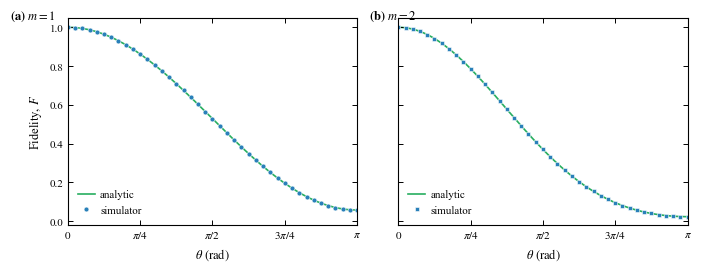

In [6]:
"""
Method I, m=1 and m=2 CTC qubits: simulator vs analytic.

Analytic:  F_I^(m)(theta) = prod_i [cos^2(theta/2) + n_{x,i}^2 sin^2(theta/2)]

Output: PDF + 600-dpi PNG to /Users/nandan/Desktop/CTCs/IBM/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── PRX-style figure conventions ────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.grid': False,
})

COLOR_SIM      = '#2980B9'   # simulator
COLOR_ANALYTIC = '#27AE60'   # analytic

OUTDIR = '/Users/nandan/Desktop/CTCs/IBM/'
os.makedirs(OUTDIR, exist_ok=True)

# Message states. First matches the n=1 paper convention; second is arbitrary.
MSG_PARAMS = [
    (2.5349076035276403, 2.0022404587009195, 0.0),
    (1.1071487177940904, 0.7853981633974483, 0.0),
]


# ── Circuit builder: Method I on n parallel CTCs ────────────────────────────
def build_method1_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C'); E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R'); G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M'); A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()

    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()

    for i in range(n):
        qc.rx(theta_rx, E[i])
    qc.barrier()

    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i]); qc.rz(pi, A[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])

    return qc


# ── Post-select all R[i] = G[i] = 0 ─────────────────────────────────────────
def postselect_RG_allzero(psi, n):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)
    R_start, R_end = 2*n, 3*n
    G_start, G_end = 3*n, 4*n
    for i in range(len(data)):
        ok = True
        for k in range(R_start, R_end):
            if (i >> k) & 1: ok = False; break
        if not ok: continue
        for k in range(G_start, G_end):
            if (i >> k) & 1: ok = False; break
        if ok:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    return Statevector(new_data / norm), norm**2


def joint_fidelity(n, theta_rx, msg_params):
    qc = build_method1_n(n, theta_rx, msg_params)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_allzero(psi_out, n)
    if psi_post is None:
        return 0.0
    rho_full = DensityMatrix(psi_post)
    Y_qubits = list(range(6*n, 7*n))
    trace_out = [q for q in range(7*n) if q not in Y_qubits]
    rho_Y = partial_trace(rho_full, trace_out)

    qc_in = QuantumCircuit(n)
    for i, (th, ph, lm) in enumerate(msg_params):
        qc_in.u(th, ph, lm, i)
    psi_in = Statevector.from_instruction(qc_in)
    return state_fidelity(rho_Y, psi_in)


# ── Sweep theta for m=1 and m=2 ─────────────────────────────────────────────
thetas = np.linspace(0.0, np.pi, 41)
theta_dense = np.linspace(0.0, np.pi, 401)

def nx2(theta_msg, varphi_msg):
    return (np.sin(theta_msg) * np.cos(varphi_msg))**2

def F_analytic(theta_arr, msg_params):
    out = np.ones_like(theta_arr)
    for (th, ph, _) in msg_params:
        out *= np.cos(theta_arr/2)**2 + nx2(th, ph) * np.sin(theta_arr/2)**2
    return out

print("Running m=1 sweep...")
msg1 = MSG_PARAMS[:1]
F1_sim = np.array([joint_fidelity(1, t, msg1) for t in thetas])
F1_an  = F_analytic(theta_dense, msg1)
F1_an_pts = F_analytic(thetas, msg1)

print("Running m=2 sweep...")
msg2 = MSG_PARAMS[:2]
F2_sim = np.array([joint_fidelity(2, t, msg2) for t in thetas])
F2_an  = F_analytic(theta_dense, msg2)
F2_an_pts = F_analytic(thetas, msg2)

print(f"m=1: max |sim - analytic| = {np.max(np.abs(F1_sim - F1_an_pts)):.2e}")
print(f"m=2: max |sim - analytic| = {np.max(np.abs(F2_sim - F2_an_pts)):.2e}")


# ── Plot: two panels, side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8), sharey=True)

xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
xticklabels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

for ax in axes:
    ax.set_xlim(0, np.pi)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel(r'$\theta\ \mathrm{(rad)}$')

# Panel (a): m = 1
ax = axes[0]
ax.plot(theta_dense, F1_an, '-', color=COLOR_ANALYTIC, lw=1.2,
        label='analytic', zorder=1)
ax.plot(thetas, F1_sim, 'o', color=COLOR_SIM, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4,
        label='simulator', zorder=2)
ax.set_ylabel(r'Fidelity, $F$')
ax.text(-0.20, 1.04, r'$\mathbf{(a)}\ m=1$', transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')
ax.legend(loc='lower left', frameon=False, handlelength=1.5, handletextpad=0.5)

# Panel (b): m = 2
ax = axes[1]
ax.plot(theta_dense, F2_an, '-', color=COLOR_ANALYTIC, lw=1.2,
        label='analytic', zorder=1)
ax.plot(thetas, F2_sim, 's', color=COLOR_SIM, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4,
        label='simulator', zorder=2)
ax.text(-0.10, 1.04, r'$\mathbf{(b)}\ m=2$', transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')
ax.legend(loc='lower left', frameon=False, handlelength=1.5, handletextpad=0.5)

plt.tight_layout(w_pad=1.0)

pdf_path = os.path.join(OUTDIR, 'method1_m1_m2_fidelity.pdf')
png_path = os.path.join(OUTDIR, 'method1_m1_m2_fidelity.png')
plt.savefig(pdf_path)
plt.savefig(png_path, dpi=600)
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

Running m=1 sweep...
Running m=2 sweep...
m=1: max |sim - analytic| = 6.66e-16
m=2: max |sim - analytic| = 5.55e-16
Saved: /Users/nandan/Desktop/CTCs/IBM/method1_m1_m2_fidelity.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/method1_m1_m2_fidelity.png


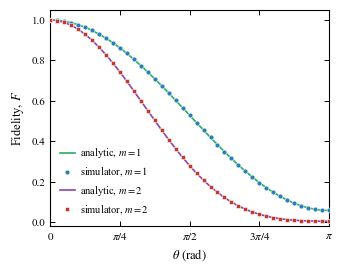

In [7]:
"""
Method I, m=1 and m=2 CTC qubits: simulator vs analytic.

Analytic:  F_I^(m)(theta) = prod_i [cos^2(theta/2) + n_{x,i}^2 sin^2(theta/2)]

Output: PDF + 600-dpi PNG to /Users/nandan/Desktop/CTCs/IBM/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── PRX-style figure conventions ────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.grid': False,
})

COLOR_SIM      = '#2980B9'   # simulator
COLOR_ANALYTIC = '#27AE60'   # analytic

OUTDIR = '/Users/nandan/Desktop/CTCs/IBM/'
os.makedirs(OUTDIR, exist_ok=True)

# Message states. First matches the n=1 paper convention; second is arbitrary.
MSG_PARAMS = [
    (2.5349076035276403, 2.0022404587009195, 0.0),
    (2.5349076035276403, 2.0022404587009195, 0.0),  # same as #1 for visible m-scaling
]


# ── Circuit builder: Method I on n parallel CTCs ────────────────────────────
def build_method1_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C'); E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R'); G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M'); A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()

    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()

    for i in range(n):
        qc.rx(theta_rx, E[i])
    qc.barrier()

    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i]); qc.rz(pi, A[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])

    return qc


# ── Post-select all R[i] = G[i] = 0 ─────────────────────────────────────────
def postselect_RG_allzero(psi, n):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)
    R_start, R_end = 2*n, 3*n
    G_start, G_end = 3*n, 4*n
    for i in range(len(data)):
        ok = True
        for k in range(R_start, R_end):
            if (i >> k) & 1: ok = False; break
        if not ok: continue
        for k in range(G_start, G_end):
            if (i >> k) & 1: ok = False; break
        if ok:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    return Statevector(new_data / norm), norm**2


def joint_fidelity(n, theta_rx, msg_params):
    qc = build_method1_n(n, theta_rx, msg_params)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_allzero(psi_out, n)
    if psi_post is None:
        return 0.0
    rho_full = DensityMatrix(psi_post)
    Y_qubits = list(range(6*n, 7*n))
    trace_out = [q for q in range(7*n) if q not in Y_qubits]
    rho_Y = partial_trace(rho_full, trace_out)

    qc_in = QuantumCircuit(n)
    for i, (th, ph, lm) in enumerate(msg_params):
        qc_in.u(th, ph, lm, i)
    psi_in = Statevector.from_instruction(qc_in)
    return state_fidelity(rho_Y, psi_in)


# ── Sweep theta for m=1 and m=2 ─────────────────────────────────────────────
thetas = np.linspace(0.0, np.pi, 41)
theta_dense = np.linspace(0.0, np.pi, 401)

def nx2(theta_msg, varphi_msg):
    return (np.sin(theta_msg) * np.cos(varphi_msg))**2

def F_analytic(theta_arr, msg_params):
    out = np.ones_like(theta_arr)
    for (th, ph, _) in msg_params:
        out *= np.cos(theta_arr/2)**2 + nx2(th, ph) * np.sin(theta_arr/2)**2
    return out

print("Running m=1 sweep...")
msg1 = MSG_PARAMS[:1]
F1_sim = np.array([joint_fidelity(1, t, msg1) for t in thetas])
F1_an  = F_analytic(theta_dense, msg1)
F1_an_pts = F_analytic(thetas, msg1)

print("Running m=2 sweep...")
msg2 = MSG_PARAMS[:2]
F2_sim = np.array([joint_fidelity(2, t, msg2) for t in thetas])
F2_an  = F_analytic(theta_dense, msg2)
F2_an_pts = F_analytic(thetas, msg2)

print(f"m=1: max |sim - analytic| = {np.max(np.abs(F1_sim - F1_an_pts)):.2e}")
print(f"m=2: max |sim - analytic| = {np.max(np.abs(F2_sim - F2_an_pts)):.2e}")


# ── Plot: single panel, overlay m=1 and m=2 ─────────────────────────────────
COLOR_M1 = '#2980B9'   # blue
COLOR_M2 = '#C0392B'   # red
COLOR_M1_AN = '#27AE60'  # green for analytic curves
COLOR_M2_AN = '#8E44AD'  # purple for second analytic

fig, ax = plt.subplots(figsize=(3.5, 2.8))

xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
xticklabels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

ax.set_xlim(0, np.pi)
ax.set_ylim(-0.02, 1.05)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel(r'$\theta\ \mathrm{(rad)}$')
ax.set_ylabel(r'Fidelity, $F$')

# m = 1
ax.plot(theta_dense, F1_an, '-', color=COLOR_M1_AN, lw=1.2, zorder=1,
        label=r'analytic, $m=1$')
ax.plot(thetas, F1_sim, 'o', color=COLOR_M1, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=3,
        label=r'simulator, $m=1$')

# m = 2
ax.plot(theta_dense, F2_an, '-', color=COLOR_M2_AN, lw=1.2, zorder=2,
        label=r'analytic, $m=2$')
ax.plot(thetas, F2_sim, 's', color=COLOR_M2, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=4,
        label=r'simulator, $m=2$')

ax.legend(loc='lower left', frameon=False, handlelength=1.5,
          handletextpad=0.5, fontsize=7.5)

plt.tight_layout()

pdf_path = os.path.join(OUTDIR, 'method1_m1_m2_fidelity.pdf')
png_path = os.path.join(OUTDIR, 'method1_m1_m2_fidelity.png')
plt.savefig(pdf_path)
plt.savefig(png_path, dpi=600)
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

Running m=1 sweep...
Running m=2 sweep...
m=1: max |sim - analytic| = 4.44e-16
m=2: max |sim - analytic| = 5.55e-16
Saved: /Users/nandan/Desktop/CTCs/IBM/method2_m1_m2_fidelity.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/method2_m1_m2_fidelity.png


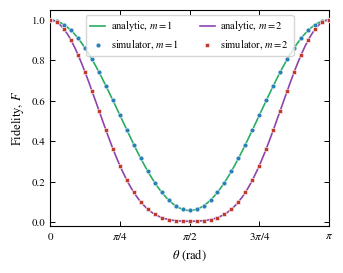

In [2]:
"""
Method II, m=1 and m=2 CTC qubits: simulator vs analytic.

Analytic:  F_II^(m)(theta) = prod_i [cos^2(theta) + n_{x,i}^2 sin^2(theta)]

Output: PDF + 600-dpi PNG to /Users/nandan/Desktop/CTCs/IBM/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── PRX-style figure conventions ────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.grid': False,
})

OUTDIR = '/Users/nandan/Desktop/CTCs/IBM/'
os.makedirs(OUTDIR, exist_ok=True)

# Two identical message states so m=2 curve is the square of m=1
MSG_PARAMS_M1 = [(2.5349076035276403, 2.0022404587009195, 0.0)]
MSG_PARAMS_M2 = [(2.5349076035276403, 2.0022404587009195, 0.0),
                 (2.5349076035276403, 2.0022404587009195, 0.0)]


# ── Method II circuit on n parallel CTCs ────────────────────────────────────
def build_method2_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C'); E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R'); G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M'); A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()

    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()

    # Method II: conjugate sandwich on E around scrambler
    for i in range(n):
        qc.rx(theta_rx, E[i])
    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])
    for i in range(n):
        qc.rx(-theta_rx, E[i])
    qc.barrier()

    # Decoder block 1 with M-sandwich
    for i in range(n):
        qc.rx(theta_rx, M[i])
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
    for i in range(n):
        qc.rx(-theta_rx, M[i])
    qc.barrier()

    # Grover (R,G)
    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])
    qc.barrier()

    # Decoder block 2 with M-sandwich
    for i in range(n):
        qc.rx(theta_rx, M[i])
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
    for i in range(n):
        qc.rx(-theta_rx, M[i])
    qc.barrier()

    # Grover (A,Y)
    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i]); qc.rz(pi, A[i])
    qc.barrier()

    # Decoder block 3 with M-sandwich
    for i in range(n):
        qc.rx(theta_rx, M[i])
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
    for i in range(n):
        qc.rx(-theta_rx, M[i])
    qc.barrier()

    # Grover (R,G) again
    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])
    qc.barrier()

    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])

    return qc


# ── Post-select all R[i] = G[i] = 0 ─────────────────────────────────────────
def postselect_RG_allzero(psi, n):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)
    R_start, R_end = 2*n, 3*n
    G_start, G_end = 3*n, 4*n
    for i in range(len(data)):
        ok = True
        for k in range(R_start, R_end):
            if (i >> k) & 1: ok = False; break
        if not ok: continue
        for k in range(G_start, G_end):
            if (i >> k) & 1: ok = False; break
        if ok:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    return Statevector(new_data / norm), norm**2


def joint_fidelity(n, theta_rx, msg_params):
    qc = build_method2_n(n, theta_rx, msg_params)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_allzero(psi_out, n)
    if psi_post is None:
        return 0.0
    rho_full = DensityMatrix(psi_post)
    Y_qubits = list(range(6*n, 7*n))
    trace_out = [q for q in range(7*n) if q not in Y_qubits]
    rho_Y = partial_trace(rho_full, trace_out)

    qc_in = QuantumCircuit(n)
    for i, (th, ph, lm) in enumerate(msg_params):
        qc_in.u(th, ph, lm, i)
    psi_in = Statevector.from_instruction(qc_in)
    return state_fidelity(rho_Y, psi_in)


# ── Sweep theta ─────────────────────────────────────────────────────────────
thetas = np.linspace(0.0, np.pi, 41)
theta_dense = np.linspace(0.0, np.pi, 401)

def nx2(theta_msg, varphi_msg):
    return (np.sin(theta_msg) * np.cos(varphi_msg))**2

def F_analytic_method2(theta_arr, msg_params):
    out = np.ones_like(theta_arr)
    for (th, ph, _) in msg_params:
        out *= np.cos(theta_arr)**2 + nx2(th, ph) * np.sin(theta_arr)**2
    return out

print("Running m=1 sweep...")
F1_sim = np.array([joint_fidelity(1, t, MSG_PARAMS_M1) for t in thetas])
F1_an  = F_analytic_method2(theta_dense, MSG_PARAMS_M1)
F1_an_pts = F_analytic_method2(thetas, MSG_PARAMS_M1)

print("Running m=2 sweep...")
F2_sim = np.array([joint_fidelity(2, t, MSG_PARAMS_M2) for t in thetas])
F2_an  = F_analytic_method2(theta_dense, MSG_PARAMS_M2)
F2_an_pts = F_analytic_method2(thetas, MSG_PARAMS_M2)

print(f"m=1: max |sim - analytic| = {np.max(np.abs(F1_sim - F1_an_pts)):.2e}")
print(f"m=2: max |sim - analytic| = {np.max(np.abs(F2_sim - F2_an_pts)):.2e}")


# ── Plot ────────────────────────────────────────────────────────────────────
COLOR_M1 = '#2980B9'   # blue
COLOR_M2 = '#C0392B'   # red
COLOR_M1_AN = '#27AE60'  # green
COLOR_M2_AN = '#8E44AD'  # purple

fig, ax = plt.subplots(figsize=(3.5, 2.8))

xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
xticklabels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

ax.set_xlim(0, np.pi)
ax.set_ylim(-0.02, 1.05)
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel(r'$\theta\ \mathrm{(rad)}$')
ax.set_ylabel(r'Fidelity, $F$')

ax.plot(theta_dense, F1_an, '-', color=COLOR_M1_AN, lw=1.2, zorder=1,
        label=r'analytic, $m=1$')
ax.plot(thetas, F1_sim, 'o', color=COLOR_M1, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=3,
        label=r'simulator, $m=1$')

ax.plot(theta_dense, F2_an, '-', color=COLOR_M2_AN, lw=1.2, zorder=2,
        label=r'analytic, $m=2$')
ax.plot(thetas, F2_sim, 's', color=COLOR_M2, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=4,
        label=r'simulator, $m=2$')

ax.legend(loc='upper center', frameon=True, handlelength=1.5,
          handletextpad=0.5, fontsize=7.5, ncol=2)

plt.tight_layout()

pdf_path = os.path.join(OUTDIR, 'method2_m1_m2_fidelity.pdf')
png_path = os.path.join(OUTDIR, 'method2_m1_m2_fidelity.png')
plt.savefig(pdf_path)
plt.savefig(png_path, dpi=600)
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

Method I, m=1...
Method I, m=2...
Method II, m=1...
Method II, m=2...
Method I  m=1 residual = 6.66e-16
Method I  m=2 residual = 5.55e-16
Method II m=1 residual = 4.44e-16
Method II m=2 residual = 5.55e-16
Saved: /Users/nandan/Desktop/CTCs/IBM/methods_combined_m1_m2_fidelity.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/methods_combined_m1_m2_fidelity.png


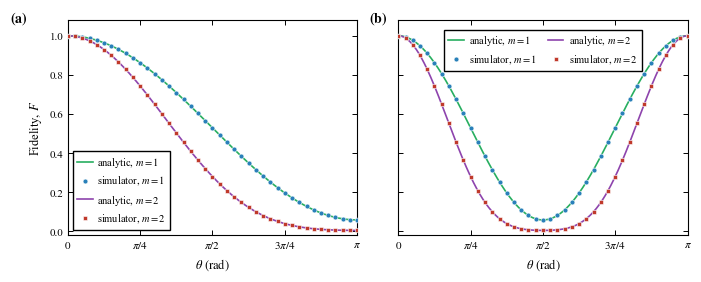

In [3]:
"""
Combined two-panel figure for the paper:
  (a) Method I,  m=1 and m=2
  (b) Method II, m=1 and m=2

Both panels: simulator points + analytic curves.

Output: PDF + 600-dpi PNG to /Users/nandan/Desktop/CTCs/IBM/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── PRX-style figure conventions ────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.grid': False,
})

OUTDIR = '/Users/nandan/Desktop/CTCs/IBM/'
os.makedirs(OUTDIR, exist_ok=True)

MSG_M1 = [(2.5349076035276403, 2.0022404587009195, 0.0)]
MSG_M2 = [(2.5349076035276403, 2.0022404587009195, 0.0)] * 2


# ── Method I circuit ────────────────────────────────────────────────────────
def build_method1_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C'); E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R'); G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M'); A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()

    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()

    for i in range(n):
        qc.rx(theta_rx, E[i])
    qc.barrier()

    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i]); qc.rz(pi, A[i])

    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])

    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])
    return qc


# ── Method II circuit ───────────────────────────────────────────────────────
def build_method2_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C'); E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R'); G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M'); A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')
    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])
    for i in range(n):
        qc.swap(C[i], M[i])
    qc.barrier()

    for i in range(n):
        qc.h(E[i]); qc.cx(E[i], M[i])
        qc.h(R[i]); qc.cx(R[i], G[i])
        qc.h(A[i]); qc.cx(A[i], Y[i])
    qc.barrier()

    # E-sandwich around scrambler
    for i in range(n):
        qc.rx(theta_rx, E[i])
    for i in range(n):
        qc.cz(C[i], R[i]); qc.cz(E[i], R[i]); qc.cz(C[i], E[i])
        qc.h(C[i]); qc.h(E[i]); qc.h(R[i])
        qc.cz(C[i], R[i]); qc.cz(C[i], E[i]); qc.cz(E[i], R[i])
    for i in range(n):
        qc.rx(-theta_rx, E[i])
    qc.barrier()

    # Decoder block 1 with M-sandwich
    for i in range(n): qc.rx(theta_rx, M[i])
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
    for i in range(n): qc.rx(-theta_rx, M[i])
    qc.barrier()

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])
    qc.barrier()

    # Decoder block 2 with M-sandwich
    for i in range(n): qc.rx(theta_rx, M[i])
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
    for i in range(n): qc.rx(-theta_rx, M[i])
    qc.barrier()

    for i in range(n):
        qc.rz(pi, A[i]); qc.rx(pi, A[i])
        qc.rx(pi, Y[i]); qc.swap(A[i], Y[i]); qc.rz(pi, A[i])
    qc.barrier()

    # Decoder block 3 with M-sandwich
    for i in range(n): qc.rx(theta_rx, M[i])
    for i in range(n):
        qc.cz(A[i], G[i]); qc.cz(M[i], A[i]); qc.cz(G[i], M[i])
        qc.h(A[i]); qc.h(M[i]); qc.h(G[i])
        qc.cz(A[i], G[i]); qc.cz(G[i], M[i]); qc.cz(M[i], A[i])
    for i in range(n): qc.rx(-theta_rx, M[i])
    qc.barrier()

    for i in range(n):
        qc.rz(pi, R[i]); qc.rx(pi, R[i])
        qc.rx(pi, G[i]); qc.swap(R[i], G[i]); qc.rz(pi, R[i])
    qc.barrier()

    for i in range(n):
        qc.cx(R[i], G[i]); qc.h(R[i])
    return qc


# ── Post-selection and joint fidelity ───────────────────────────────────────
def postselect_RG_allzero(psi, n):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)
    R_start, R_end = 2*n, 3*n
    G_start, G_end = 3*n, 4*n
    for i in range(len(data)):
        ok = True
        for k in range(R_start, R_end):
            if (i >> k) & 1: ok = False; break
        if not ok: continue
        for k in range(G_start, G_end):
            if (i >> k) & 1: ok = False; break
        if ok:
            new_data[i] = data[i]
    norm = np.linalg.norm(new_data)
    if norm == 0:
        return None, 0.0
    return Statevector(new_data / norm), norm**2


def joint_fidelity(builder, n, theta_rx, msg_params):
    qc = builder(n, theta_rx, msg_params)
    psi_out = Statevector.from_instruction(qc)
    psi_post, p_succ = postselect_RG_allzero(psi_out, n)
    if psi_post is None:
        return 0.0
    rho_full = DensityMatrix(psi_post)
    Y_qubits = list(range(6*n, 7*n))
    trace_out = [q for q in range(7*n) if q not in Y_qubits]
    rho_Y = partial_trace(rho_full, trace_out)

    qc_in = QuantumCircuit(n)
    for i, (th, ph, lm) in enumerate(msg_params):
        qc_in.u(th, ph, lm, i)
    psi_in = Statevector.from_instruction(qc_in)
    return state_fidelity(rho_Y, psi_in)


# ── Sweep ───────────────────────────────────────────────────────────────────
thetas = np.linspace(0.0, np.pi, 41)
theta_dense = np.linspace(0.0, np.pi, 401)

def nx2(theta_msg, varphi_msg):
    return (np.sin(theta_msg) * np.cos(varphi_msg))**2

def F_an(method, theta_arr, msg_params):
    """Analytic: method I uses theta/2; method II uses theta."""
    out = np.ones_like(theta_arr)
    if method == 1:
        for (th, ph, _) in msg_params:
            out *= np.cos(theta_arr/2)**2 + nx2(th, ph) * np.sin(theta_arr/2)**2
    else:
        for (th, ph, _) in msg_params:
            out *= np.cos(theta_arr)**2 + nx2(th, ph) * np.sin(theta_arr)**2
    return out


print("Method I, m=1...");  F1_I_sim = np.array([joint_fidelity(build_method1_n, 1, t, MSG_M1) for t in thetas])
print("Method I, m=2...");  F2_I_sim = np.array([joint_fidelity(build_method1_n, 2, t, MSG_M2) for t in thetas])
print("Method II, m=1..."); F1_II_sim = np.array([joint_fidelity(build_method2_n, 1, t, MSG_M1) for t in thetas])
print("Method II, m=2..."); F2_II_sim = np.array([joint_fidelity(build_method2_n, 2, t, MSG_M2) for t in thetas])

F1_I_an  = F_an(1, theta_dense, MSG_M1)
F2_I_an  = F_an(1, theta_dense, MSG_M2)
F1_II_an = F_an(2, theta_dense, MSG_M1)
F2_II_an = F_an(2, theta_dense, MSG_M2)

print(f"Method I  m=1 residual = {np.max(np.abs(F1_I_sim  - F_an(1, thetas, MSG_M1))):.2e}")
print(f"Method I  m=2 residual = {np.max(np.abs(F2_I_sim  - F_an(1, thetas, MSG_M2))):.2e}")
print(f"Method II m=1 residual = {np.max(np.abs(F1_II_sim - F_an(2, thetas, MSG_M1))):.2e}")
print(f"Method II m=2 residual = {np.max(np.abs(F2_II_sim - F_an(2, thetas, MSG_M2))):.2e}")


# ── Plot ────────────────────────────────────────────────────────────────────
COLOR_M1     = '#2980B9'    # blue (sim m=1)
COLOR_M2     = '#C0392B'    # red  (sim m=2)
COLOR_M1_AN  = '#27AE60'    # green (analytic m=1)
COLOR_M2_AN  = '#8E44AD'    # purple (analytic m=2)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True)

xticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
xticklabels = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']

for ax in axes:
    ax.set_xlim(0, np.pi)
    ax.set_ylim(-0.02, 1.08)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel(r'$\theta\ \mathrm{(rad)}$')

# Panel (a): Method I
ax = axes[0]
ax.plot(theta_dense, F1_I_an, '-', color=COLOR_M1_AN, lw=1.2, zorder=1,
        label=r'analytic, $m=1$')
ax.plot(thetas, F1_I_sim, 'o', color=COLOR_M1, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=3,
        label=r'simulator, $m=1$')
ax.plot(theta_dense, F2_I_an, '-', color=COLOR_M2_AN, lw=1.2, zorder=2,
        label=r'analytic, $m=2$')
ax.plot(thetas, F2_I_sim, 's', color=COLOR_M2, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=4,
        label=r'simulator, $m=2$')
ax.set_ylabel(r'Fidelity, $F$')
ax.text(-0.20, 1.05, r'$\mathbf{(a)}$', transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top')
ax.legend(loc='lower left', frameon=True, handlelength=1.5,
          handletextpad=0.4, ncol=1, framealpha=1.0,
          edgecolor='black', fancybox=False)

# Panel (b): Method II
ax = axes[1]
ax.plot(theta_dense, F1_II_an, '-', color=COLOR_M1_AN, lw=1.2, zorder=1,
        label=r'analytic, $m=1$')
ax.plot(thetas, F1_II_sim, 'o', color=COLOR_M1, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=3,
        label=r'simulator, $m=1$')
ax.plot(theta_dense, F2_II_an, '-', color=COLOR_M2_AN, lw=1.2, zorder=2,
        label=r'analytic, $m=2$')
ax.plot(thetas, F2_II_sim, 's', color=COLOR_M2, markersize=3.5,
        markeredgecolor='white', markeredgewidth=0.4, zorder=4,
        label=r'simulator, $m=2$')
ax.text(-0.10, 1.05, r'$\mathbf{(b)}$', transform=ax.transAxes,
        fontsize=10, fontweight='bold', va='top')

# leg = ax.legend(
#     loc='upper center',
#     bbox_to_anchor=(0.5, 0.98),   # x=center, y=near top of axes
#     frameon=True,
#     handlelength=1.5,
#     handletextpad=0.5,
#     ncol=2,
#     columnspacing=1.0,
#     framealpha=1.0,
#     facecolor='white',            # legend box fill color
#     edgecolor='black',            # legend box border color
#     fancybox=False,
#     borderpad=0.35
# )

# leg.get_frame().set_linewidth(0.8)   # legend box border width


ax.legend(loc='upper center', frameon=True, handlelength=1.5,
          handletextpad=0.5, ncol=2, columnspacing=1.0,
          bbox_to_anchor=(0.5, 0.98), framealpha=1.0,
          edgecolor='black', fancybox=False)


# ax.legend(loc='upper center', frameon=False, handlelength=1.5,
#           handletextpad=0.5, fontsize=7.5, ncol=2)

plt.tight_layout(w_pad=1.0)

pdf_path = os.path.join(OUTDIR, 'methods_combined_m1_m2_fidelity.pdf')
png_path = os.path.join(OUTDIR, 'methods_combined_m1_m2_fidelity.png')
plt.savefig(pdf_path)
plt.savefig(png_path, dpi=600)
print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")

Method I, m=1...
Method I, m=2...
Method II, m=1...
Method II, m=2...
Method I  m=1 residual = 6.66e-16
Method I  m=2 residual = 5.55e-16
Method II m=1 residual = 4.44e-16
Method II m=2 residual = 5.55e-16
Saved: /Users/nandan/Desktop/CTCs/IBM/methods_combined_m1_m2_fidelity.pdf
Saved: /Users/nandan/Desktop/CTCs/IBM/methods_combined_m1_m2_fidelity.png


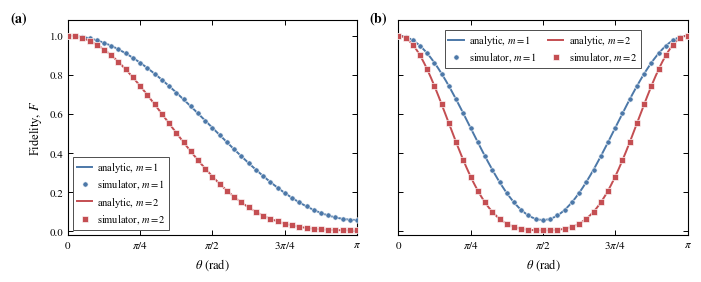

In [6]:
"""
Combined two-panel figure for the paper:
  (a) Method I,  m=1 and m=2
  (b) Method II, m=1 and m=2

Both panels: simulator points + analytic curves.

Output: PDF + 600-dpi PNG to /Users/nandan/Desktop/CTCs/IBM/.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from math import pi

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import (
    Statevector, DensityMatrix, partial_trace, state_fidelity
)

# ── PRX-style figure conventions ────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'STIX Two Text', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.grid': False,
})

OUTDIR = '/Users/nandan/Desktop/CTCs/IBM/'
os.makedirs(OUTDIR, exist_ok=True)

MSG_M1 = [(2.5349076035276403, 2.0022404587009195, 0.0)]
MSG_M2 = [(2.5349076035276403, 2.0022404587009195, 0.0)] * 2


# ── Method I circuit ────────────────────────────────────────────────────────
def build_method1_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C')
    E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R')
    G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M')
    A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')

    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])

    for i in range(n):
        qc.swap(C[i], M[i])

    qc.barrier()

    for i in range(n):
        qc.h(E[i])
        qc.cx(E[i], M[i])

        qc.h(R[i])
        qc.cx(R[i], G[i])

        qc.h(A[i])
        qc.cx(A[i], Y[i])

    qc.barrier()

    for i in range(n):
        qc.rx(theta_rx, E[i])

    qc.barrier()

    for i in range(n):
        qc.cz(C[i], R[i])
        qc.cz(E[i], R[i])
        qc.cz(C[i], E[i])

        qc.h(C[i])
        qc.h(E[i])
        qc.h(R[i])

        qc.cz(C[i], R[i])
        qc.cz(C[i], E[i])
        qc.cz(E[i], R[i])

    for i in range(n):
        qc.cz(A[i], G[i])
        qc.cz(M[i], A[i])
        qc.cz(G[i], M[i])

        qc.h(A[i])
        qc.h(M[i])
        qc.h(G[i])

        qc.cz(A[i], G[i])
        qc.cz(G[i], M[i])
        qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i])
        qc.rx(pi, R[i])
        qc.rx(pi, G[i])
        qc.swap(R[i], G[i])
        qc.rz(pi, R[i])

    for i in range(n):
        qc.cz(A[i], G[i])
        qc.cz(M[i], A[i])
        qc.cz(G[i], M[i])

        qc.h(A[i])
        qc.h(M[i])
        qc.h(G[i])

        qc.cz(A[i], G[i])
        qc.cz(G[i], M[i])
        qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, A[i])
        qc.rx(pi, A[i])
        qc.rx(pi, Y[i])
        qc.swap(A[i], Y[i])
        qc.rz(pi, A[i])

    for i in range(n):
        qc.cz(A[i], G[i])
        qc.cz(M[i], A[i])
        qc.cz(G[i], M[i])

        qc.h(A[i])
        qc.h(M[i])
        qc.h(G[i])

        qc.cz(A[i], G[i])
        qc.cz(G[i], M[i])
        qc.cz(M[i], A[i])

    for i in range(n):
        qc.rz(pi, R[i])
        qc.rx(pi, R[i])
        qc.rx(pi, G[i])
        qc.swap(R[i], G[i])
        qc.rz(pi, R[i])

    for i in range(n):
        qc.cx(R[i], G[i])
        qc.h(R[i])

    return qc


# ── Method II circuit ───────────────────────────────────────────────────────
def build_method2_n(n, theta_rx, msg_params):
    C = QuantumRegister(n, 'C')
    E = QuantumRegister(n, 'E')
    R = QuantumRegister(n, 'R')
    G = QuantumRegister(n, 'G')
    M = QuantumRegister(n, 'M')
    A = QuantumRegister(n, 'A')
    Y = QuantumRegister(n, 'Y')

    qc = QuantumCircuit(C, E, R, G, M, A, Y)

    for i, (th, ph, lm) in enumerate(msg_params):
        qc.u(th, ph, lm, M[i])

    for i in range(n):
        qc.swap(C[i], M[i])

    qc.barrier()

    for i in range(n):
        qc.h(E[i])
        qc.cx(E[i], M[i])

        qc.h(R[i])
        qc.cx(R[i], G[i])

        qc.h(A[i])
        qc.cx(A[i], Y[i])

    qc.barrier()

    # E-sandwich around scrambler
    for i in range(n):
        qc.rx(theta_rx, E[i])

    for i in range(n):
        qc.cz(C[i], R[i])
        qc.cz(E[i], R[i])
        qc.cz(C[i], E[i])

        qc.h(C[i])
        qc.h(E[i])
        qc.h(R[i])

        qc.cz(C[i], R[i])
        qc.cz(C[i], E[i])
        qc.cz(E[i], R[i])

    for i in range(n):
        qc.rx(-theta_rx, E[i])

    qc.barrier()

    # Decoder block 1 with M-sandwich
    for i in range(n):
        qc.rx(theta_rx, M[i])

    for i in range(n):
        qc.cz(A[i], G[i])
        qc.cz(M[i], A[i])
        qc.cz(G[i], M[i])

        qc.h(A[i])
        qc.h(M[i])
        qc.h(G[i])

        qc.cz(A[i], G[i])
        qc.cz(G[i], M[i])
        qc.cz(M[i], A[i])

    for i in range(n):
        qc.rx(-theta_rx, M[i])

    qc.barrier()

    for i in range(n):
        qc.rz(pi, R[i])
        qc.rx(pi, R[i])
        qc.rx(pi, G[i])
        qc.swap(R[i], G[i])
        qc.rz(pi, R[i])

    qc.barrier()

    # Decoder block 2 with M-sandwich
    for i in range(n):
        qc.rx(theta_rx, M[i])

    for i in range(n):
        qc.cz(A[i], G[i])
        qc.cz(M[i], A[i])
        qc.cz(G[i], M[i])

        qc.h(A[i])
        qc.h(M[i])
        qc.h(G[i])

        qc.cz(A[i], G[i])
        qc.cz(G[i], M[i])
        qc.cz(M[i], A[i])

    for i in range(n):
        qc.rx(-theta_rx, M[i])

    qc.barrier()

    for i in range(n):
        qc.rz(pi, A[i])
        qc.rx(pi, A[i])
        qc.rx(pi, Y[i])
        qc.swap(A[i], Y[i])
        qc.rz(pi, A[i])

    qc.barrier()

    # Decoder block 3 with M-sandwich
    for i in range(n):
        qc.rx(theta_rx, M[i])

    for i in range(n):
        qc.cz(A[i], G[i])
        qc.cz(M[i], A[i])
        qc.cz(G[i], M[i])

        qc.h(A[i])
        qc.h(M[i])
        qc.h(G[i])

        qc.cz(A[i], G[i])
        qc.cz(G[i], M[i])
        qc.cz(M[i], A[i])

    for i in range(n):
        qc.rx(-theta_rx, M[i])

    qc.barrier()

    for i in range(n):
        qc.rz(pi, R[i])
        qc.rx(pi, R[i])
        qc.rx(pi, G[i])
        qc.swap(R[i], G[i])
        qc.rz(pi, R[i])

    qc.barrier()

    for i in range(n):
        qc.cx(R[i], G[i])
        qc.h(R[i])

    return qc


# ── Post-selection and joint fidelity ───────────────────────────────────────
def postselect_RG_allzero(psi, n):
    data = psi.data
    new_data = np.zeros_like(data, dtype=complex)

    R_start, R_end = 2 * n, 3 * n
    G_start, G_end = 3 * n, 4 * n

    for i in range(len(data)):
        ok = True

        for k in range(R_start, R_end):
            if (i >> k) & 1:
                ok = False
                break

        if not ok:
            continue

        for k in range(G_start, G_end):
            if (i >> k) & 1:
                ok = False
                break

        if ok:
            new_data[i] = data[i]

    norm = np.linalg.norm(new_data)

    if norm == 0:
        return None, 0.0

    return Statevector(new_data / norm), norm**2


def joint_fidelity(builder, n, theta_rx, msg_params):
    qc = builder(n, theta_rx, msg_params)
    psi_out = Statevector.from_instruction(qc)

    psi_post, p_succ = postselect_RG_allzero(psi_out, n)

    if psi_post is None:
        return 0.0

    rho_full = DensityMatrix(psi_post)

    Y_qubits = list(range(6 * n, 7 * n))
    trace_out = [q for q in range(7 * n) if q not in Y_qubits]

    rho_Y = partial_trace(rho_full, trace_out)

    qc_in = QuantumCircuit(n)
    for i, (th, ph, lm) in enumerate(msg_params):
        qc_in.u(th, ph, lm, i)

    psi_in = Statevector.from_instruction(qc_in)

    return state_fidelity(rho_Y, psi_in)


# ── Sweep ───────────────────────────────────────────────────────────────────
thetas = np.linspace(0.0, np.pi, 41)
theta_dense = np.linspace(0.0, np.pi, 401)


def nx2(theta_msg, varphi_msg):
    return (np.sin(theta_msg) * np.cos(varphi_msg))**2


def F_an(method, theta_arr, msg_params):
    """
    Analytic fidelity.

    Method I:
        F(theta) = prod_j [cos^2(theta/2) + n_x,j^2 sin^2(theta/2)]

    Method II:
        F(theta) = prod_j [cos^2(theta) + n_x,j^2 sin^2(theta)]
    """
    out = np.ones_like(theta_arr)

    if method == 1:
        for (th, ph, _) in msg_params:
            out *= np.cos(theta_arr / 2)**2 + nx2(th, ph) * np.sin(theta_arr / 2)**2
    else:
        for (th, ph, _) in msg_params:
            out *= np.cos(theta_arr)**2 + nx2(th, ph) * np.sin(theta_arr)**2

    return out


print("Method I, m=1...")
F1_I_sim = np.array([
    joint_fidelity(build_method1_n, 1, t, MSG_M1)
    for t in thetas
])

print("Method I, m=2...")
F2_I_sim = np.array([
    joint_fidelity(build_method1_n, 2, t, MSG_M2)
    for t in thetas
])

print("Method II, m=1...")
F1_II_sim = np.array([
    joint_fidelity(build_method2_n, 1, t, MSG_M1)
    for t in thetas
])

print("Method II, m=2...")
F2_II_sim = np.array([
    joint_fidelity(build_method2_n, 2, t, MSG_M2)
    for t in thetas
])

F1_I_an = F_an(1, theta_dense, MSG_M1)
F2_I_an = F_an(1, theta_dense, MSG_M2)
F1_II_an = F_an(2, theta_dense, MSG_M1)
F2_II_an = F_an(2, theta_dense, MSG_M2)

print(
    f"Method I  m=1 residual = "
    f"{np.max(np.abs(F1_I_sim - F_an(1, thetas, MSG_M1))):.2e}"
)
print(
    f"Method I  m=2 residual = "
    f"{np.max(np.abs(F2_I_sim - F_an(1, thetas, MSG_M2))):.2e}"
)
print(
    f"Method II m=1 residual = "
    f"{np.max(np.abs(F1_II_sim - F_an(2, thetas, MSG_M1))):.2e}"
)
print(
    f"Method II m=2 residual = "
    f"{np.max(np.abs(F2_II_sim - F_an(2, thetas, MSG_M2))):.2e}"
)


# ── Plot ────────────────────────────────────────────────────────────────────
# Color meaning:
#   blue = m = 1
#   red  = m = 2
#
# Style meaning:
#   solid line = analytic prediction
#   marker     = simulator result

COLOR_M1 = '#4C78A8'   # muted blue
COLOR_M2 = '#C44E52'   # muted red

# COLOR_M1 = '#26415a'   # muted blue
# COLOR_M2 = '#8c3b3b'   # muted red


# M1_COLOR = "#26415a"   # slate-navy
# M2_COLOR = "#8c3b3b"   # brick

COLOR_M1_AN = COLOR_M1
COLOR_M2_AN = COLOR_M2

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True)

xticks = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi]
xticklabels = [
    r'$0$',
    r'$\pi/4$',
    r'$\pi/2$',
    r'$3\pi/4$',
    r'$\pi$'
]

for ax in axes:
    ax.set_xlim(0, np.pi)
    ax.set_ylim(-0.02, 1.08)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel(r'$\theta\ \mathrm{(rad)}$')


# Panel (a): Method I
ax = axes[0]

ax.plot(
    theta_dense,
    F1_I_an,
    '-',
    color=COLOR_M1_AN,
    lw=1.4,
    zorder=1,
    label=r'analytic, $m=1$'
)

ax.plot(
    thetas,
    F1_I_sim,
    'o',
    color=COLOR_M1,
    markersize=3.8,
    markeredgecolor='white',
    markeredgewidth=0.45,
    zorder=3,
    label=r'simulator, $m=1$'
)

ax.plot(
    theta_dense,
    F2_I_an,
    '-',
    color=COLOR_M2_AN,
    lw=1.4,
    zorder=2,
    label=r'analytic, $m=2$'
)

ax.plot(
    thetas,
    F2_I_sim,
    's',
    color=COLOR_M2,
    markersize=3.8,
    markeredgecolor='white',
    markeredgewidth=0.45,
    zorder=4,
    label=r'simulator, $m=2$'
)

ax.set_ylabel(r'Fidelity, $F$')

ax.text(
    -0.20,
    1.05,
    r'$\mathbf{(a)}$',
    transform=ax.transAxes,
    fontsize=10,
    fontweight='bold',
    va='top'
)

leg0 = ax.legend(
    loc='lower left',
    frameon=True,
    handlelength=1.5,
    handletextpad=0.4,
    ncol=1,
    framealpha=1.0,
    facecolor='white',
    edgecolor='0.3',
    fancybox=False,
    borderpad=0.35,
    labelspacing=0.35
)
leg0.get_frame().set_linewidth(0.7)


# Panel (b): Method II
ax = axes[1]

ax.plot(
    theta_dense,
    F1_II_an,
    '-',
    color=COLOR_M1_AN,
    lw=1.4,
    zorder=1,
    label=r'analytic, $m=1$'
)

ax.plot(
    thetas,
    F1_II_sim,
    'o',
    color=COLOR_M1,
    markersize=3.8,
    markeredgecolor='white',
    markeredgewidth=0.45,
    zorder=3,
    label=r'simulator, $m=1$'
)

ax.plot(
    theta_dense,
    F2_II_an,
    '-',
    color=COLOR_M2_AN,
    lw=1.4,
    zorder=2,
    label=r'analytic, $m=2$'
)

ax.plot(
    thetas,
    F2_II_sim,
    's',
    color=COLOR_M2,
    markersize=3.8,
    markeredgecolor='white',
    markeredgewidth=0.45,
    zorder=4,
    label=r'simulator, $m=2$'
)

ax.text(
    -0.10,
    1.05,
    r'$\mathbf{(b)}$',
    transform=ax.transAxes,
    fontsize=10,
    fontweight='bold',
    va='top'
)

leg1 = ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    frameon=True,
    handlelength=1.5,
    handletextpad=0.5,
    ncol=2,
    columnspacing=1.0,
    framealpha=1.0,
    facecolor='white',
    edgecolor='0.3',
    fancybox=False,
    borderpad=0.35,
    labelspacing=0.35
)
leg1.get_frame().set_linewidth(0.7)


plt.tight_layout(w_pad=1.0)

pdf_path = os.path.join(OUTDIR, 'methods_combined_m1_m2_fidelity.pdf')
png_path = os.path.join(OUTDIR, 'methods_combined_m1_m2_fidelity.png')

plt.savefig(pdf_path)
plt.savefig(png_path, dpi=600)

print(f"Saved: {pdf_path}")
print(f"Saved: {png_path}")